In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,Activation
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [36]:
train_dir = 'training_set/training_set'
validation_dir = 'test_set/test_set'

# Parameters
batch_size = 16
epochs = 45
IMG_HEIGHT = 224
IMG_WIDTH = 224
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

In [37]:
from re import I
import tensorflow.keras.backend as k
if k.image_data_format() == 'channels_first':
  input_shape = (3,IMG_HEIGHT,IMG_WIDTH)
else:
  input_shape = (IMG_HEIGHT,IMG_WIDTH,3)


In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.08,
    zoom_range=0.15,

    horizontal_flip=True,   # ✅ OK
    # ❌ REMOVE vertical_flip

    brightness_range=[0.9,1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [39]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=batch_size,
    class_mode='binary',
    classes=['Cats', 'Dogs'],
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


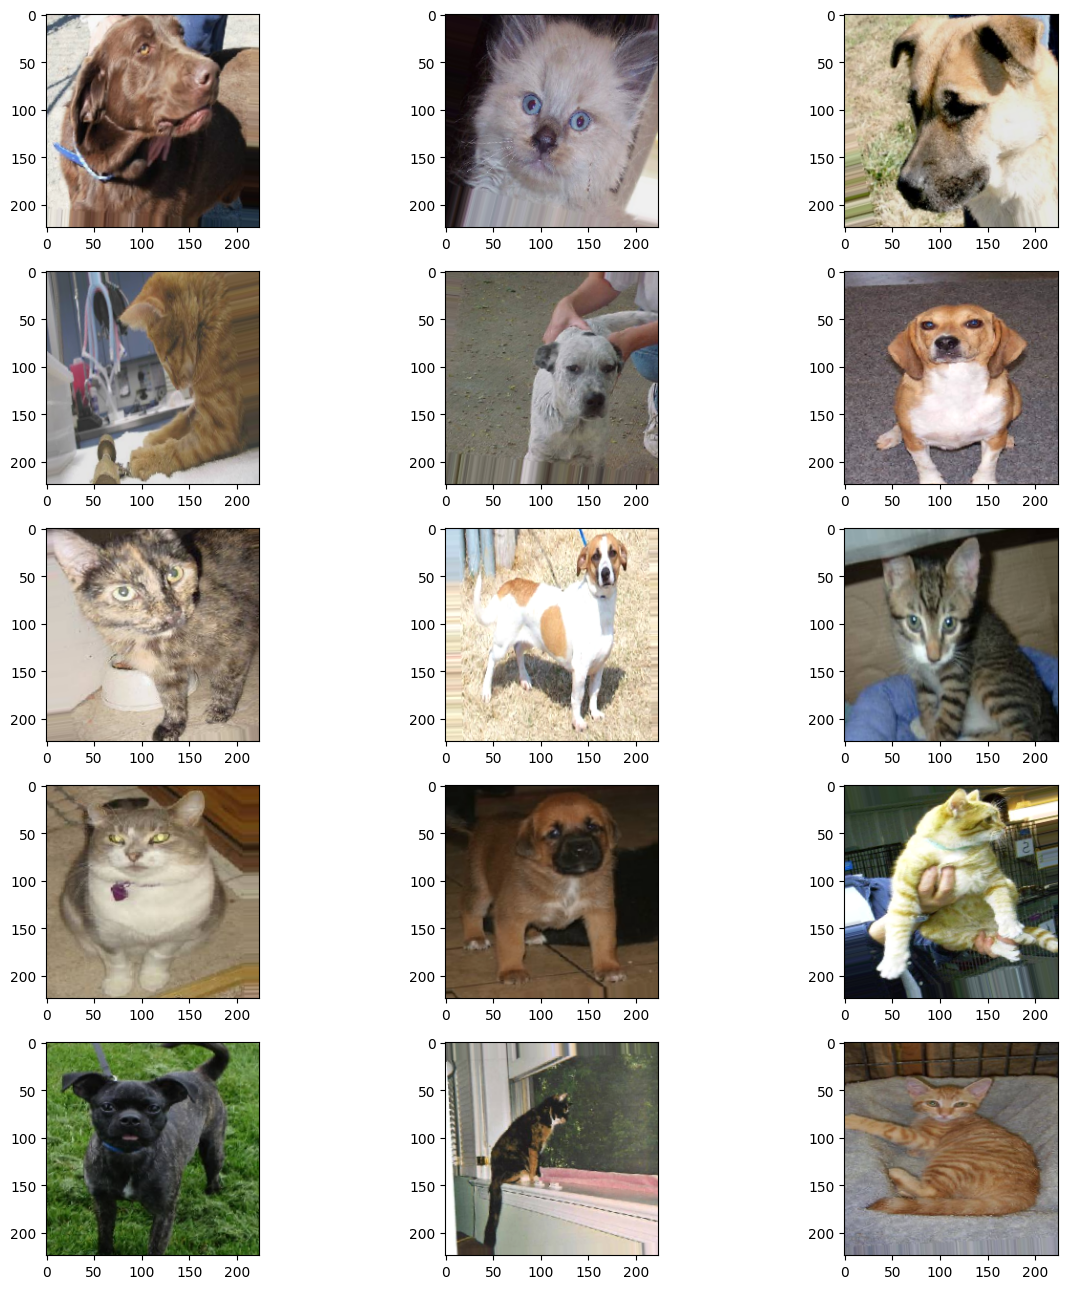

In [40]:
plt.figure(figsize=(13,13))
for i in range(0,15):
  plt.subplot(5,3,i+1)
  for x_batch,y_batch in train_generator:
    image = x_batch[0]
    plt.imshow(image)
    break
plt.tight_layout()
plt.show()

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2

model = Sequential([

    Conv2D(32,(3,3),
           activation='relu',
           kernel_regularizer=l2(0.0001),
           input_shape=(IMG_HEIGHT,IMG_WIDTH,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),
           activation='relu',
           kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),
           activation='relu',
           kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),
           activation='relu',
           kernel_regularizer=l2(0.0001)),
           
    GlobalAveragePooling2D(),

    Dense(256,activation='relu',
          kernel_regularizer=l2(0.0001)),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

c:\vinay\test\sample\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [43]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-7
)

callbacks=[early_stop,checkpoint,reduce_lr]


In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights=dict(enumerate(class_weights))


In [45]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=35,
    callbacks=callbacks,
    class_weight=class_weights
)


c:\vinay\test\sample\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - accuracy: 0.6042 - loss: 0.7240 - val_accuracy: 0.5442 - val_loss: 0.7858 - learning_rate: 3.0000e-04
Epoch 2/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.6535 - loss: 0.6765 - val_accuracy: 0.6831 - val_loss: 0.6451 - learning_rate: 3.0000e-04
Epoch 3/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 603s 1s/step - accuracy: 0.6867 - loss: 0.6427 - val_accuracy: 0.7153 - val_loss: 0.6066 - learning_rate: 3.0000e-04
Epoch 4/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 546s 1s/step - accuracy: 0.7064 - loss: 0.6160 - val_accuracy: 0.6792 - val_loss: 0.6405 - learning_rate: 3.0000e-04
Epoch 5/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 551s 1s/step - accuracy: 0.7249 - loss: 0.5982 - val_accuracy: 0.7192 - val_loss: 0.5915 - learning_rate: 3.0000e-04
Epoch 6/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.7309 - loss: 0.5880 - val_accuracy: 0.6233 - val_loss: 0.8341 - learning_rate: 3.0000e-04
Epoch 7/35
501/501 ━━━━━━━━━━━━━━━━━━━━ 536s 1s/step - acc

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


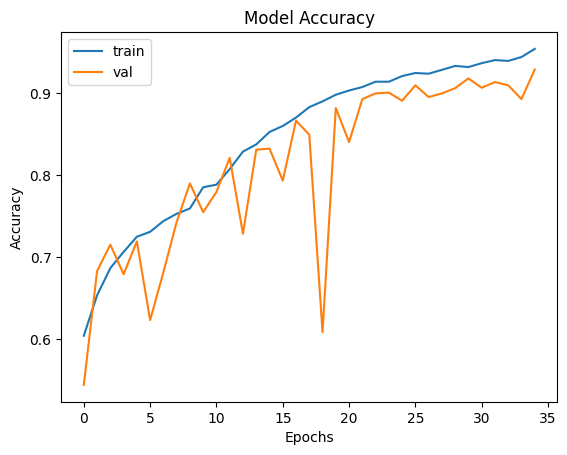

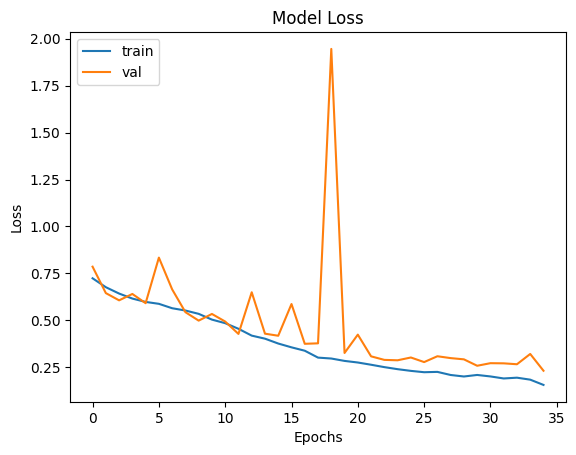

In [47]:
print(history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train','val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train','val'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[4.7050066e-09]]
Prediction: Cat


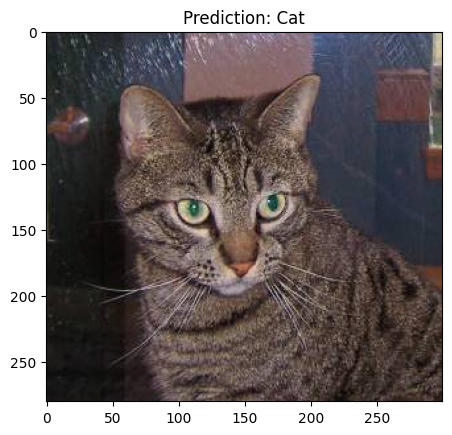

In [51]:
# image prediction
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as npimg

img_pred = image.load_img('training_set/training_set/cats/cat.2.jpg',target_size=(224,224))
img_pred = image.img_to_array(img_pred)
img_pred = np.expand_dims(img_pred,axis=0)
img_pred /= 255.0  # rescale like in datagen

rslt = model.predict(img_pred)
print(rslt)
if rslt[0][0] > 0.5:
  prediction = 'Dog'
else:
  prediction = 'Cat'

print(f"Prediction: {prediction}")

img = npimg.imread('training_set/training_set/cats/cat.1.jpg')
imgplot = plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.show()